In [ ]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Average Score
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

# Pass / Fail
df['result'] = df['average_score'].apply(
    lambda x: 1 if x >= 50 else 0
)

# Encode categorical columns

le = LabelEncoder()

categorical_columns = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result
0,0,1,1,1,1,72,72,74,72.666667,1
1,0,2,4,1,0,69,90,88,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,1


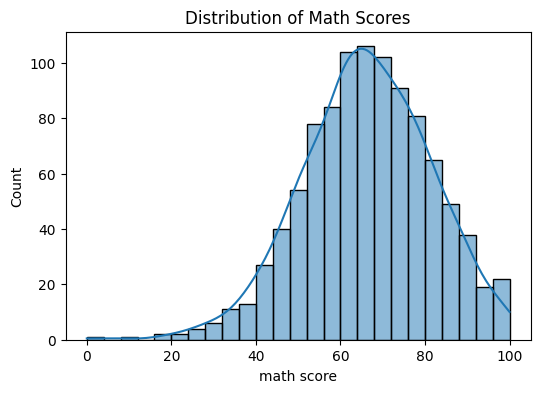

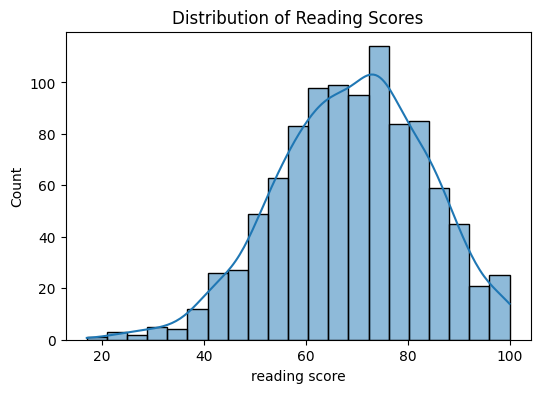

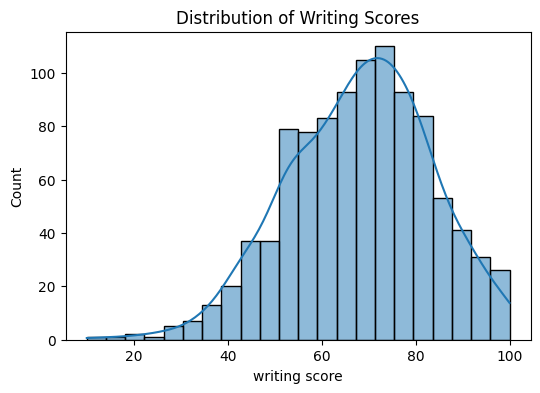

In [ ]:
# Math Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['math score'], kde=True)
plt.title("Distribution of Math Scores")
plt.show()

# Reading Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['reading score'], kde=True)
plt.title("Distribution of Reading Scores")
plt.show()

# Writing Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['writing score'], kde=True)
plt.title("Distribution of Writing Scores")
plt.show()

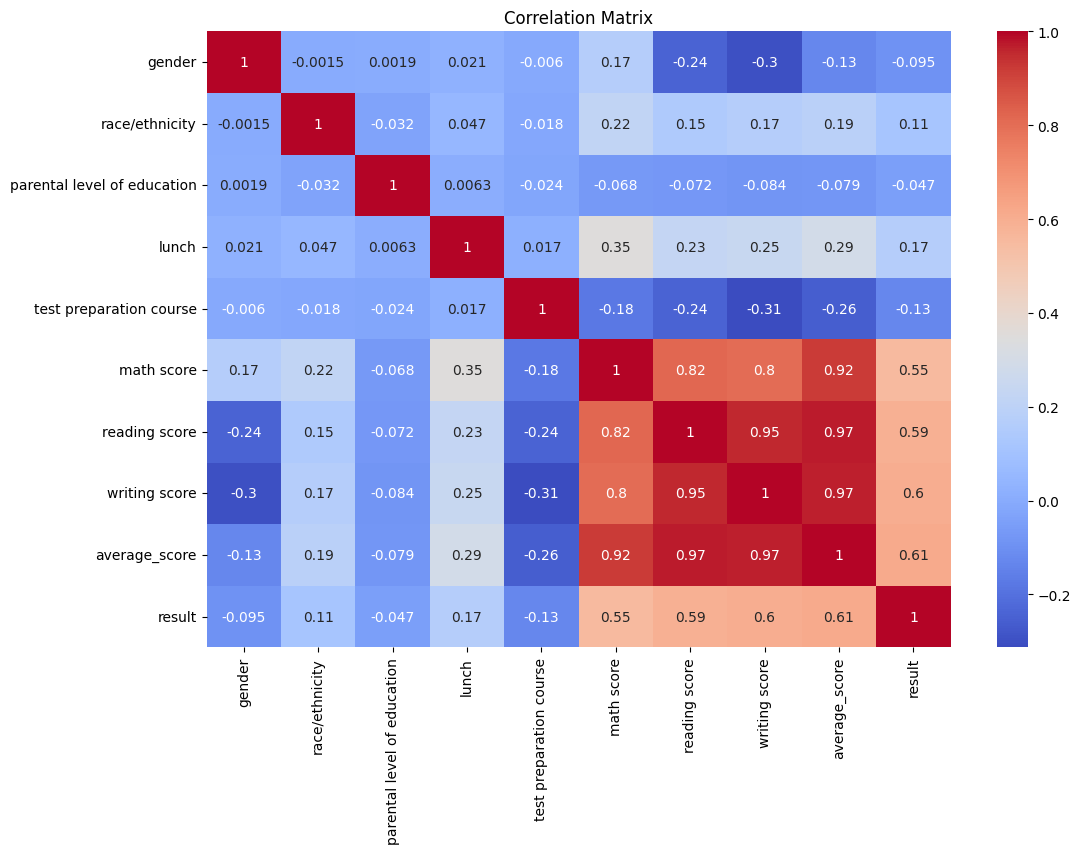

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
X = df.drop(['average_score', 'result'], axis=1)

y = df['result']

print(X.head())

   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  math score  reading score  writing score  
0                        1          72             72             74  
1                        0          69             90             88  
2                        1          90             95             93  
3                        1          47             57             44  
4                        1          76             78             75  


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 8)
(200, 8)



Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


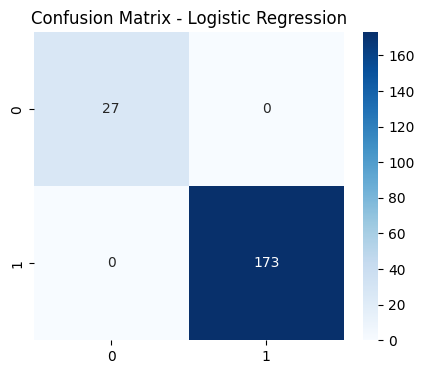


Decision Tree
Accuracy : 0.985
Precision: 0.9885057471264368
Recall   : 0.9942196531791907
F1 Score : 0.9913544668587896


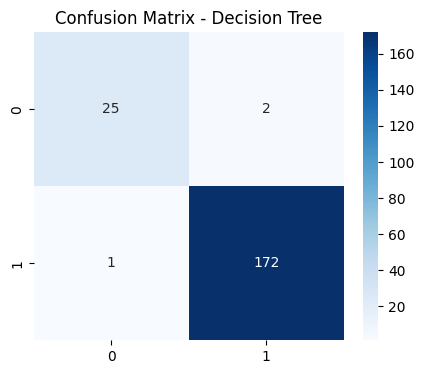


Naive Bayes
Accuracy : 0.985
Precision: 1.0
Recall   : 0.9826589595375722
F1 Score : 0.9912536443148688


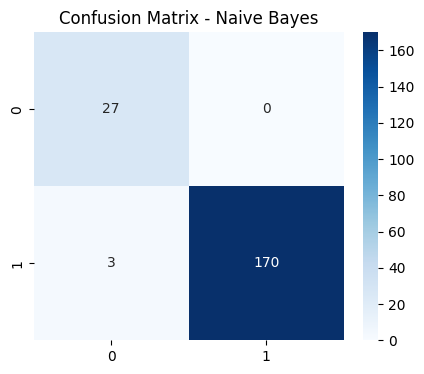


SVM
Accuracy : 0.96
Precision: 0.9558011049723757
Recall   : 1.0
F1 Score : 0.9774011299435028


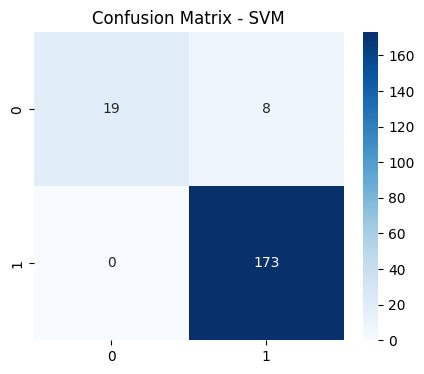


Random Forest
Accuracy : 0.995
Precision: 0.9942528735632183
Recall   : 1.0
F1 Score : 0.9971181556195965


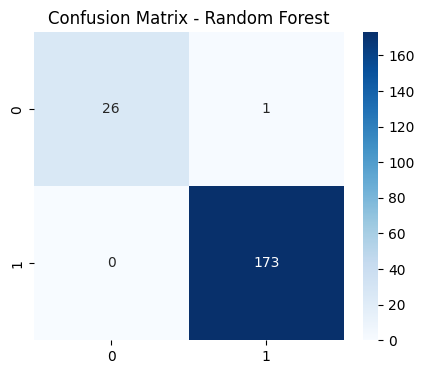

In [ ]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Naive Bayes":
    GaussianNB(),

    "SVM":
    SVC(),

    "Random Forest":
    RandomForestClassifier(n_estimators=100)
}

best_accuracy = 0
best_model = None

for name, model in models.items():

    print("\n====================")
    print(name)
    print("====================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.show()

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

In [ ]:
joblib.dump(
    best_model,
    "student_performance_model.joblib"
)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
model = joblib.load(
    "student_performance_model.joblib"
)

gender = int(input("Gender (0=Female,1=Male): "))
race = int(input("Race Group (0-4): "))
parent_edu = int(input("Parent Education (0-5): "))
lunch = int(input("Lunch (0/1): "))
test_prep = int(input("Test Prep (0/1): "))

math_score = float(input("Math Score: "))
reading_score = float(input("Reading Score: "))
writing_score = float(input("Writing Score: "))

input_data = pd.DataFrame([[
    gender,
    race,
    parent_edu,
    lunch,
    test_prep,
    math_score,
    reading_score,
    writing_score
]], columns=X.columns)

prediction = model.predict(input_data)[0]

if prediction == 1:
    print("\nSTUDENT IS LIKELY TO PASS")
else:
    print("\nSTUDENT IS LIKELY TO FAIL")

Gender (0=Female,1=Male): 1
Race Group (0-4): 4
Parent Education (0-5): 4
Lunch (0/1): 1
Test Prep (0/1): 7
Math Score: 8
Reading Score: 8
Writing Score: 9

STUDENT IS LIKELY TO FAIL


/tmp/ipykernel_3754/3970108420.py:65: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f629fe3eed73e5114d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


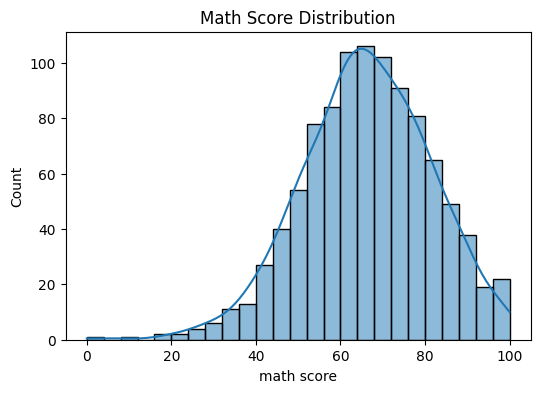

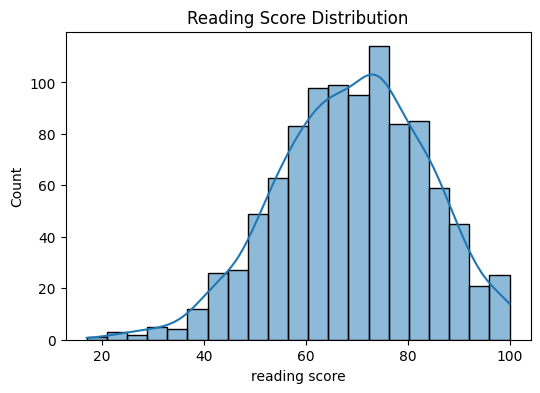

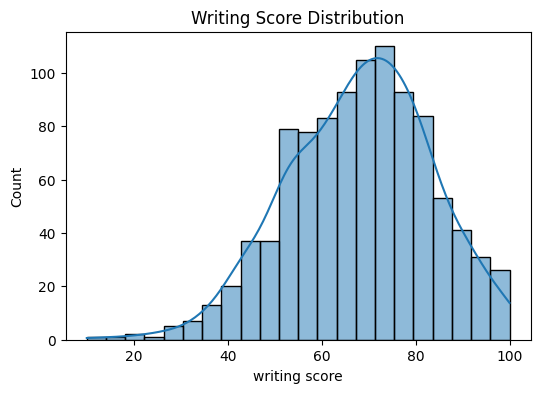

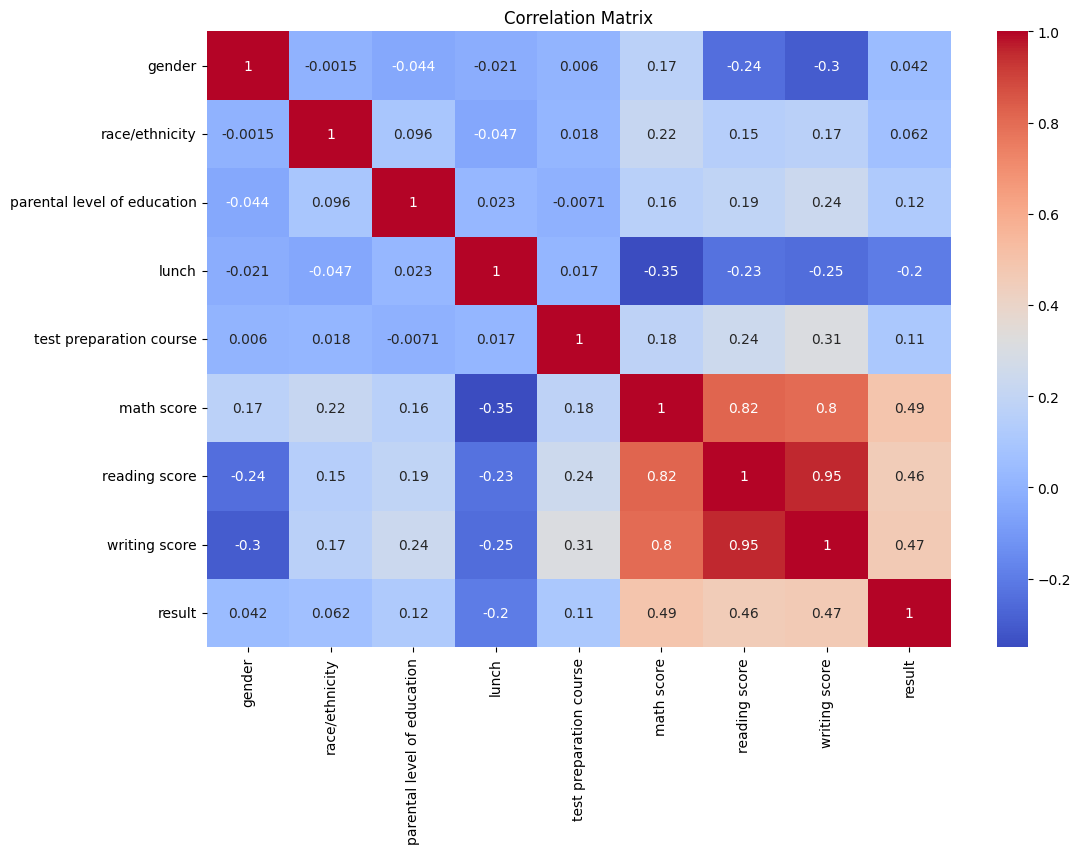

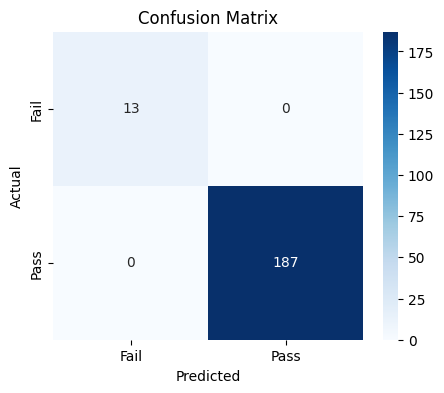

In [ ]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)

# =========================================
# FUNCTIONS
# =========================================

def predict_student(
    gender,
    race,
    parent_edu,
    lunch,
    test_prep,
    math_score,
    reading_score,
    writing_score
):

    input_data = pd.DataFrame([[
        gender,
        race,
        parent_edu,
        lunch,
        test_prep,
        math_score,
        reading_score,
        writing_score
    ]], columns=X.columns)

    prediction = model.predict(input_data)[0]

    average = (
        math_score +
        reading_score +
        writing_score
    ) / 3

    if prediction == 1:

        return f"""
        ✅ STUDENT IS LIKELY TO PASS

        Average Score: {average:.2f}
        """

    else:

        return f"""
        ❌ STUDENT IS LIKELY TO FAIL

        Average Score: {average:.2f}
        """

# =========================================
# GRADIO NAVIGATION SYSTEM
# =========================================

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    # =====================================
    # TITLE
    # =====================================

    gr.Markdown(
        """
        # 🎓 Student Performance Prediction System

        ### Major Project using Machine Learning
        """
    )

    # =====================================
    # HOME PAGE
    # =====================================

    with gr.Tab("🏠 Home"):

        gr.Markdown(
            """
            ## Welcome

            This project predicts student performance
            using Machine Learning algorithms.

            ### Navigation

            - Dataset
            - Preprocessing
            - Graphs
            - Heatmap
            - Model Training
            - Accuracy
            - Confusion Matrix
            - Prediction
            - About
            """
        )

    # =====================================
    # DATASET PAGE
    # =====================================

    with gr.Tab("📂 Dataset"):

        gr.Markdown("## Dataset Preview")

        gr.Dataframe(df.head(10))

    # =====================================
    # PREPROCESSING PAGE
    # =====================================

    with gr.Tab("⚙️ Preprocessing"):

        gr.Markdown("## Preprocessed Dataset")

        gr.Dataframe(df.head(10))

    # =====================================
    # GRAPH PAGE
    # =====================================

    with gr.Tab("📊 Graphs"):

        gr.Markdown("## Math Score Distribution")

        fig1, ax1 = plt.subplots(figsize=(6,4))

        sns.histplot(
            df['math score'],
            kde=True,
            ax=ax1
        )

        ax1.set_title("Math Score Distribution")

        gr.Plot(fig1)

        # =================================

        gr.Markdown("## Reading Score Distribution")

        fig2, ax2 = plt.subplots(figsize=(6,4))

        sns.histplot(
            df['reading score'],
            kde=True,
            ax=ax2
        )

        ax2.set_title("Reading Score Distribution")

        gr.Plot(fig2)

        # =================================

        gr.Markdown("## Writing Score Distribution")

        fig3, ax3 = plt.subplots(figsize=(6,4))

        sns.histplot(
            df['writing score'],
            kde=True,
            ax=ax3
        )

        ax3.set_title("Writing Score Distribution")

        gr.Plot(fig3)

    # =====================================
    # HEATMAP PAGE
    # =====================================

    with gr.Tab("🔥 Heatmap"):

        gr.Markdown("## Correlation Heatmap")

        fig4, ax4 = plt.subplots(figsize=(12,8))

        sns.heatmap(
            df.corr(),
            annot=True,
            cmap='coolwarm',
            ax=ax4
        )

        ax4.set_title("Correlation Matrix")

        gr.Plot(fig4)

    # =====================================
    # MODEL TRAINING PAGE
    # =====================================

    with gr.Tab("🤖 Model Training"):

        gr.Textbox(
            value="MODEL TRAINED SUCCESSFULLY",
            label="Training Status"
        )

    # =====================================
    # ACCURACY PAGE
    # =====================================

    with gr.Tab("📈 Accuracy"):

        gr.Markdown("## Model Accuracy")

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        gr.Textbox(
            value=f"Accuracy: {accuracy:.2f}",
            label="Accuracy Score"
        )

    # =====================================
    # CONFUSION MATRIX PAGE
    # =====================================

    with gr.Tab("📉 Confusion Matrix"):

        gr.Markdown("## Confusion Matrix")

        y_pred = model.predict(X_test)

        cm = confusion_matrix(
            y_test,
            y_pred
        )

        fig5, ax5 = plt.subplots(figsize=(5,4))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'],
            ax=ax5
        )

        ax5.set_xlabel("Predicted")

        ax5.set_ylabel("Actual")

        ax5.set_title("Confusion Matrix")

        gr.Plot(fig5)

    # =====================================
    # PREDICTION PAGE
    # =====================================

    with gr.Tab("🎯 Prediction"):

        gr.Markdown(
            """
            ## Student Prediction System

            Enter student details below:
            """
        )

        gender = gr.Dropdown(
            [0,1],
            label="Gender (0=Female, 1=Male)"
        )

        race = gr.Dropdown(
            [0,1,2,3,4],
            label="Race Group"
        )

        parent_edu = gr.Dropdown(
            [0,1,2,3,4,5],
            label="Parental Education"
        )

        lunch = gr.Dropdown(
            [0,1],
            label="Lunch Type"
        )

        test_prep = gr.Dropdown(
            [0,1],
            label="Test Preparation"
        )

        math_score = gr.Slider(
            0,
            100,
            value=60,
            label="Math Score"
        )

        reading_score = gr.Slider(
            0,
            100,
            value=70,
            label="Reading Score"
        )

        writing_score = gr.Slider(
            0,
            100,
            value=75,
            label="Writing Score"
        )

        prediction_output = gr.Textbox(
            label="Prediction Result"
        )

        predict_btn = gr.Button(
            "Predict Student Result"
        )

        predict_btn.click(

            fn=predict_student,

            inputs=[
                gender,
                race,
                parent_edu,
                lunch,
                test_prep,
                math_score,
                reading_score,
                writing_score
            ],

            outputs=prediction_output
        )

    # =====================================
    # ABOUT PAGE
    # =====================================

    with gr.Tab("ℹ️ About"):

        gr.Markdown(
            """
            ## Technologies Used

            - Python
            - Pandas
            - NumPy
            - Seaborn
            - Matplotlib
            - Scikit-learn
            - Gradio
            - Machine Learning

            ## Algorithms Used

            - Logistic Regression
            - Decision Tree
            - Naive Bayes
            - SVM
            - Random Forest
            """
        )

# =========================================
# LAUNCH APP
# =========================================

demo.launch(share=True)